# Import the importance Libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor

## Read the Training Dataset

In [3]:
train_df=pd.read_csv('/kaggle/input/playground-series-s5e5/train.csv')

## Show the first 5 rows

In [4]:
train_df.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


## Show information about the dataset

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 📊 Train Dataset Description

The training dataset contains **750,000 rows** and **9 columns**, each representing demographic or physiological characteristics of an individual during a physical activity session. The goal is to predict the number of **calories burnt** based on these features.

### 🔹 Column Descriptions

| Column Name   | Data Type | Description |
|---------------|-----------|-------------|
| `id`          | `int64`   | A unique identifier for each record. It is not useful for prediction and can be excluded from modeling. |
| `Sex`         | `object`  | The biological sex of the individual. Categorical feature usually taking values like `'male'` or `'female'`. |
| `Age`         | `int64`   | Age of the individual in years. This numerical feature may influence metabolic rate and calorie burn. |
| `Height`      | `float64` | Height of the individual in centimeters. Typically used to estimate body mass and fitness level. |
| `Weight`      | `float64` | Weight of the individual in kilograms. Important for calculating energy expenditure. |
| `Duration`    | `float64` | Duration of the physical activity in minutes. Longer durations typically result in higher calorie burn. |
| `Heart_Rate`  | `float64` | The average heart rate during the activity session. Higher heart rates indicate more intense activity. |
| `Body_Temp`   | `float64` | Average body temperature in degrees Celsius recorded during the session. May correlate with physical exertion. |
| `Calories`    | `float64` | 🔥 **Target Variable** – The number of calories burnt during the session. This is the continuous variable we aim to predict. |


## Show the statistical Details about the data

In [6]:
train_df.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


## Check for Missing Values

In [7]:
train_df.isna().sum()

id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

## Check for Duplicated Values

In [8]:
train_df.duplicated().sum()

0

## Check for Outliers

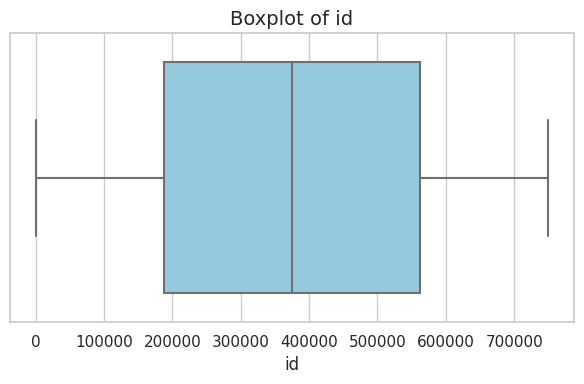

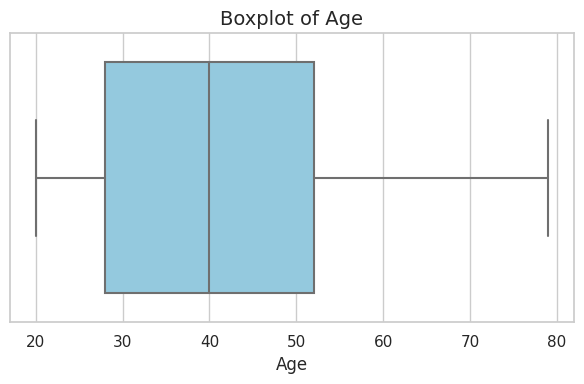

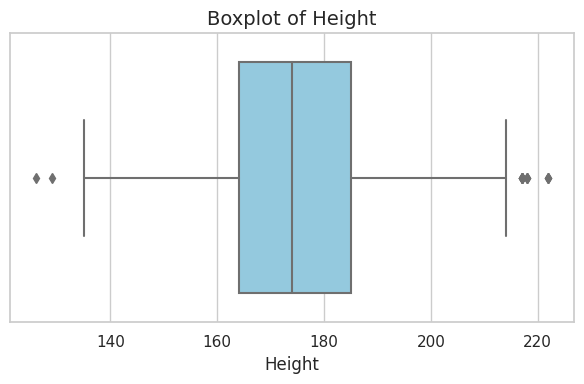

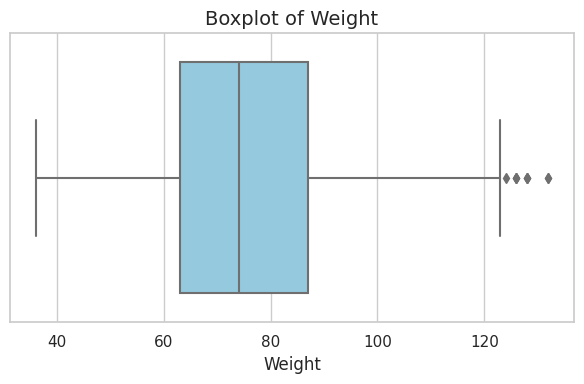

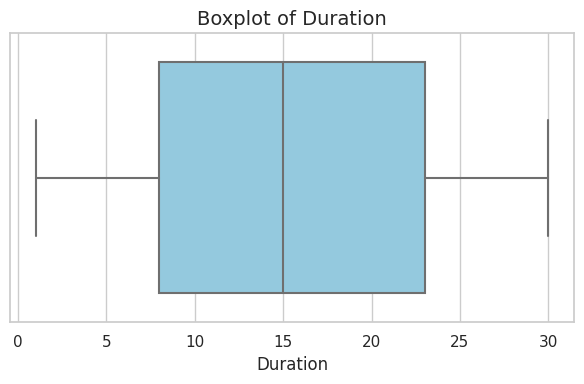

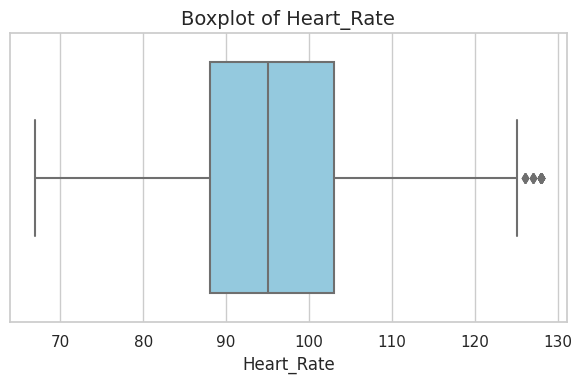

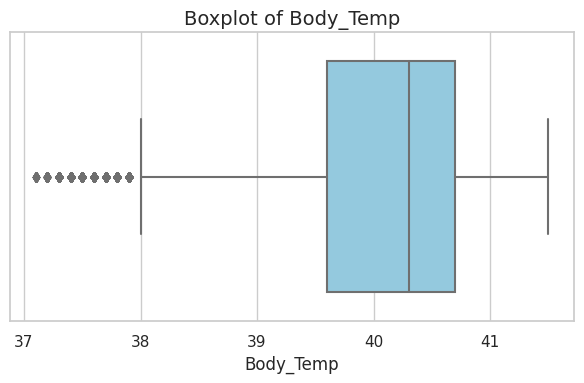

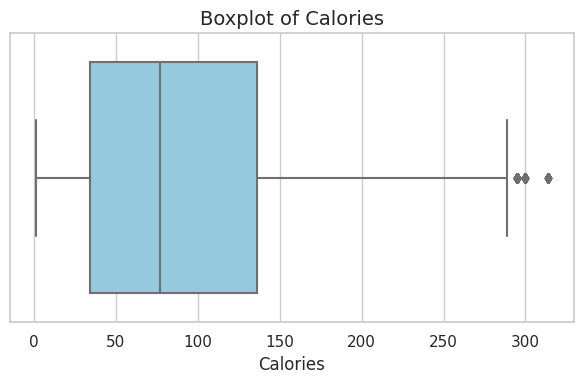

In [9]:
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
sns.set(style="whitegrid")
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=train_df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=14)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# **Exploratory Data Analysis**

## Univariate Analysis

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


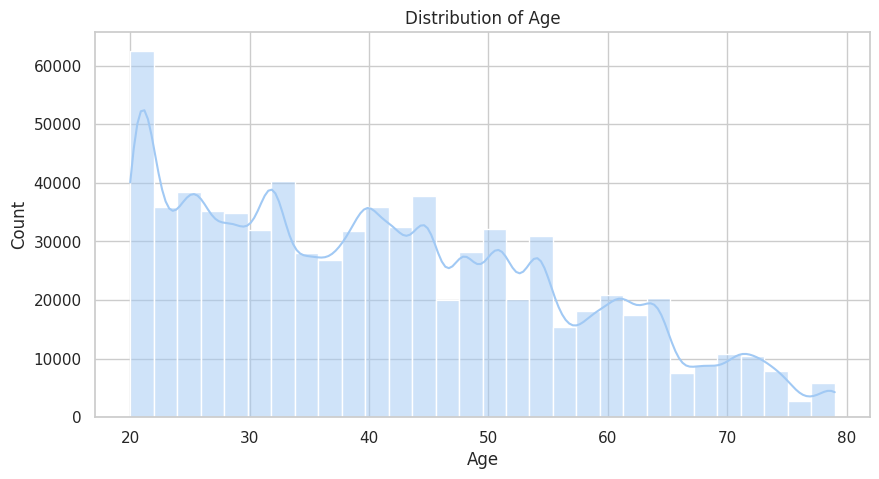

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


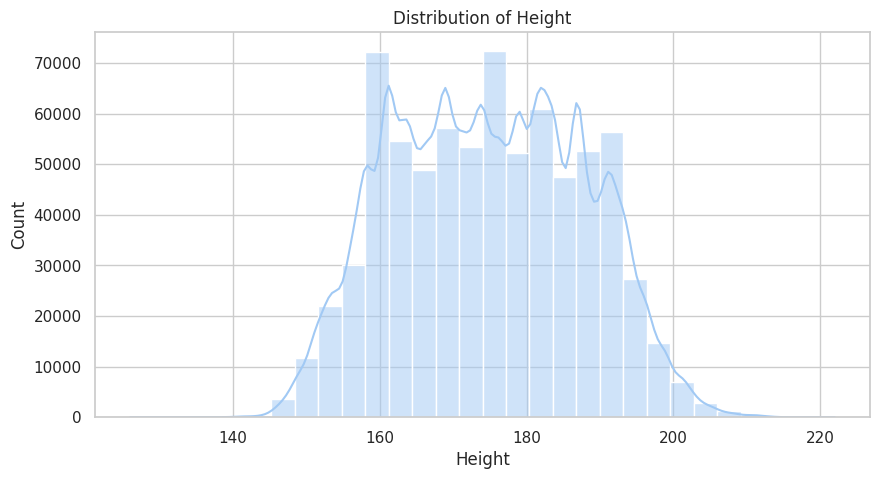

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


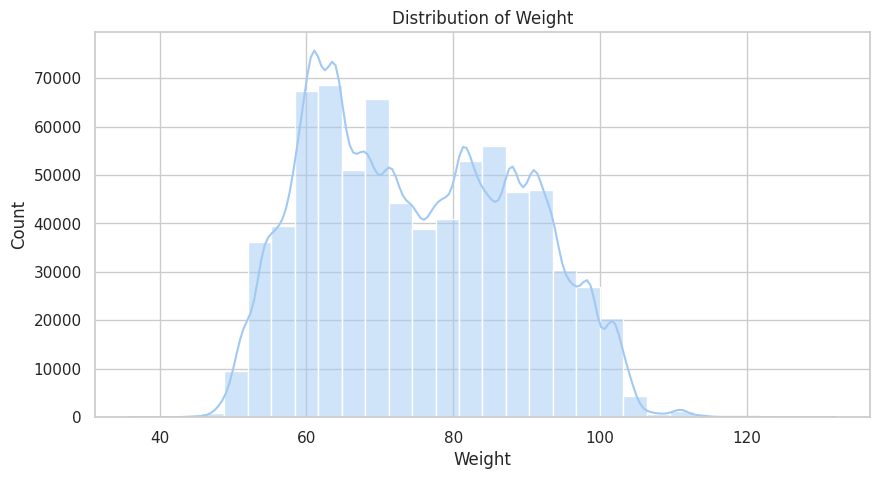

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


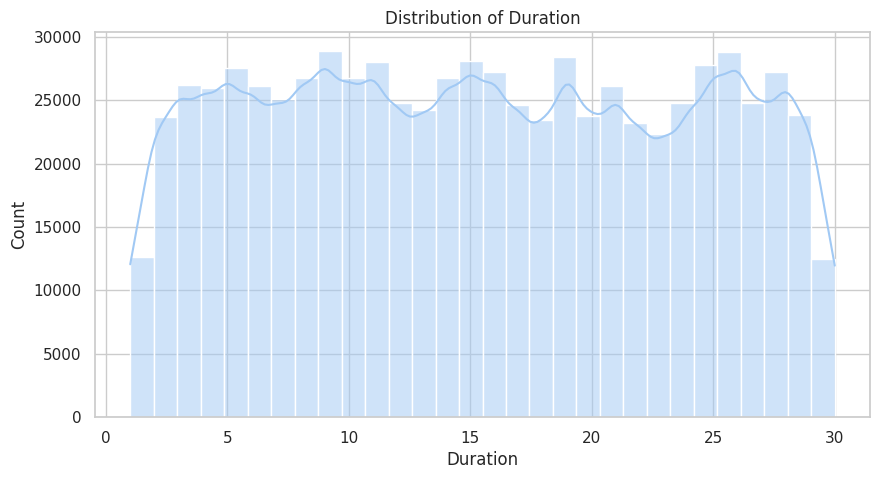

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


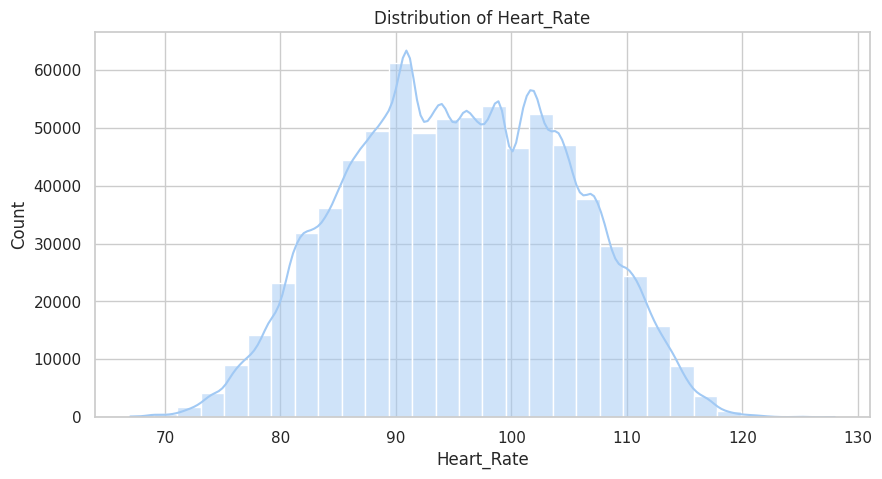

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


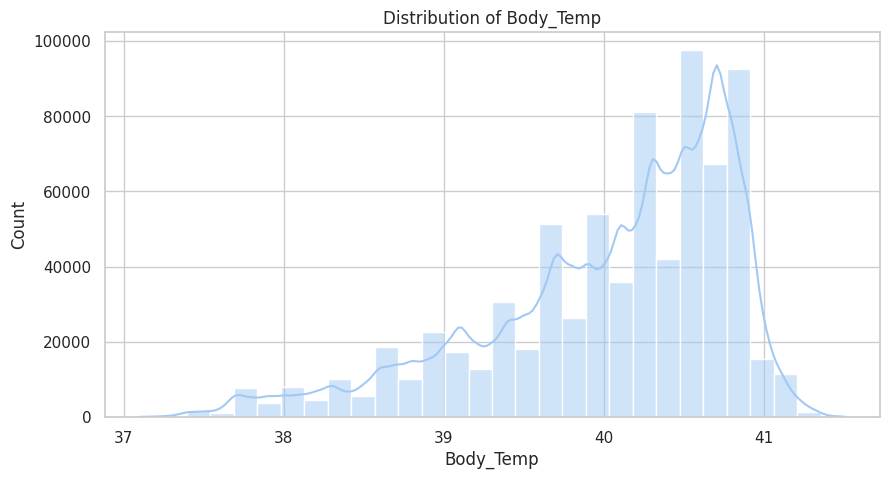

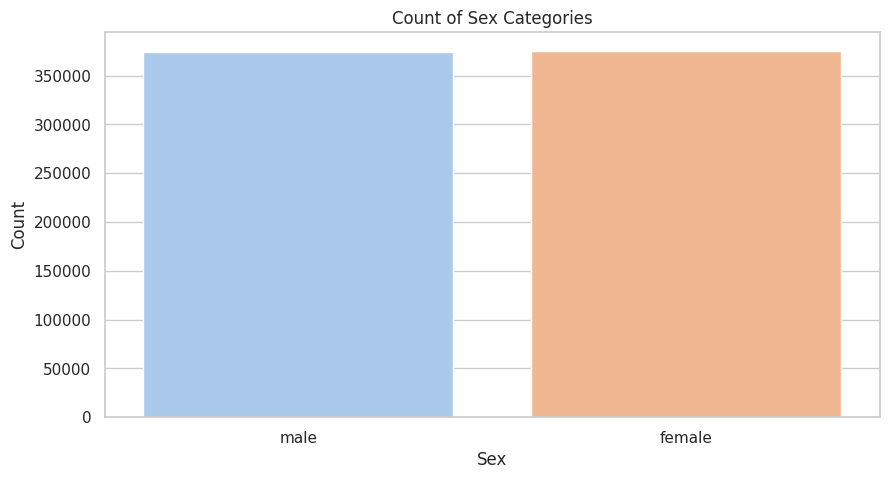

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


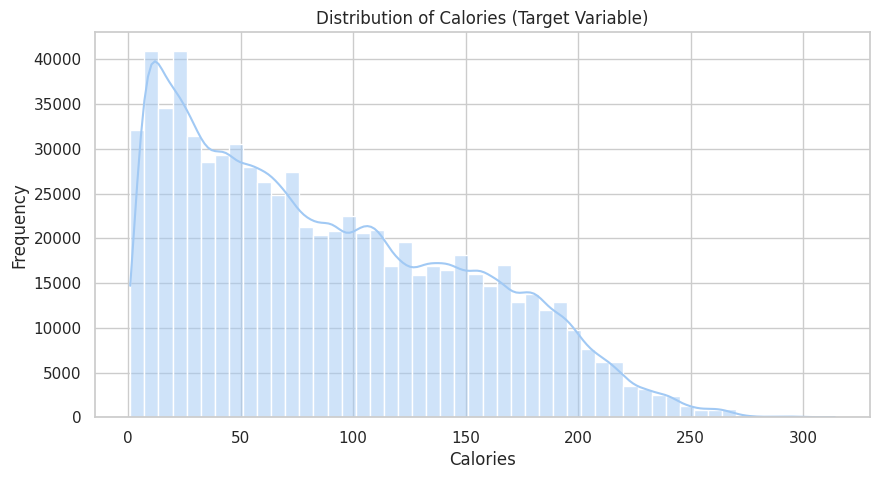

In [10]:
sns.set(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (10, 5)

# Exclude 'id' as it's not useful for visualization
features = train_df.drop(columns=['id', 'Calories']).columns

# Univariate analysis: numerical features
numeric_features = train_df.select_dtypes(include=['int64', 'float64']).drop(columns=['id', 'Calories']).columns

for col in numeric_features:
    plt.figure()
    sns.histplot(train_df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# Univariate analysis: categorical feature (Sex)
plt.figure()
sns.countplot(x='Sex', data=train_df)
plt.title('Count of Sex Categories')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

# Target Variable: Calories
plt.figure()
sns.histplot(train_df['Calories'], kde=True, bins=50)
plt.title('Distribution of Calories (Target Variable)')
plt.xlabel('Calories')
plt.ylabel('Frequency')
plt.show()

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 🔍 Univariate Analysis

Univariate analysis involves examining each feature in isolation to understand its distribution, detect outliers, and identify potential data quality issues. Here's a summary of the key observations:

### 🔹 Numerical Features

- **Age**: The distribution is roughly right-skewed, with most individuals aged between **20 and 40**. This suggests the dataset primarily represents young to middle-aged adults, likely the most active demographic.
- **Height & Weight**: Both follow a **normal-like distribution**, indicating a relatively healthy and consistent population. Outliers (very short/tall or underweight/overweight individuals) may exist but are minimal.
- **Duration**: The distribution is skewed, with most activity sessions under **40 minutes**, reflecting typical exercise routines. Longer durations are rare but can greatly impact calorie burn.
- **Heart_Rate**: Appears normally distributed, with most heart rates between **80 and 140 bpm**, aligning with moderate-to-high intensity workouts.
- **Body_Temp**: Concentrated around **37°C**, indicating normal physiological responses during activity.
- **Calories (Target)**: The target variable is right-skewed — most sessions result in **calories burnt between 100 and 500**. There are extreme values (above 800), which are likely long or intense sessions.

### 🔹 Categorical Feature

- **Sex**: The distribution between `'male'` and `'female'` is fairly balanced, ensuring no gender bias in model training.

> 🔎 **Why Univariate Analysis Matters**  
Understanding individual feature distributions helps in:
- Identifying the need for normalization or transformation (e.g., skewed data).
- Detecting outliers that may distort model performance.
- Tailoring feature engineering strategies based on spread and central tendency.


## Bivariate Analysis

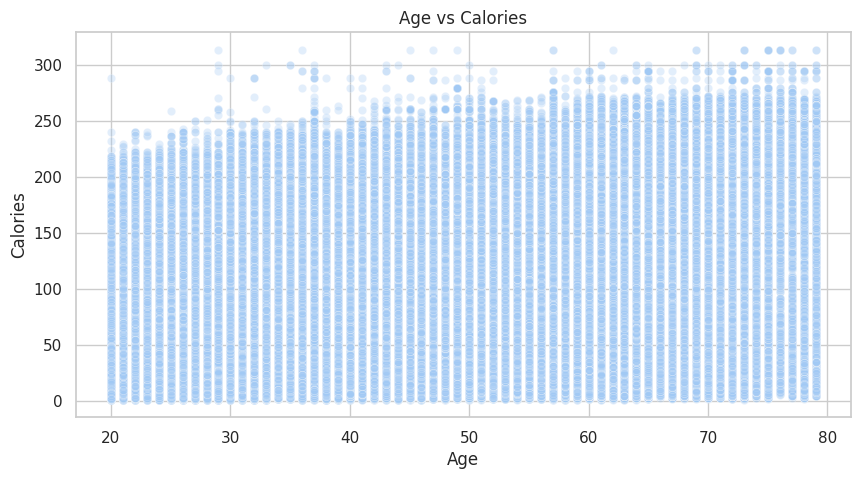

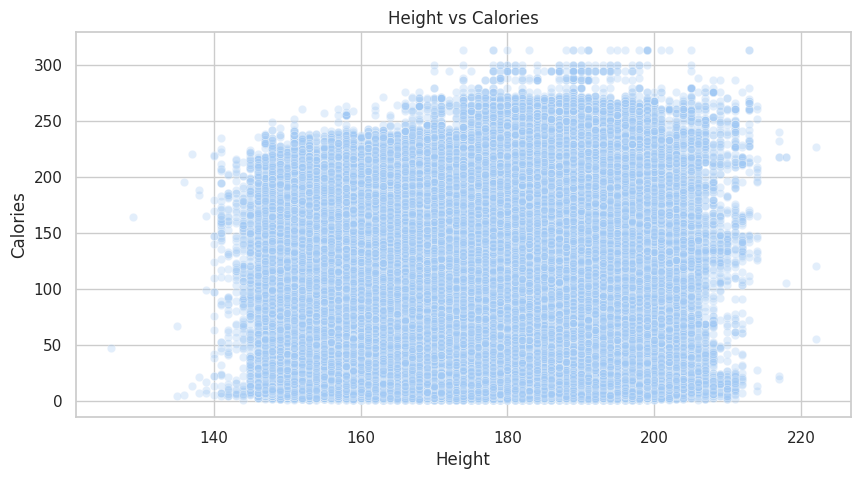

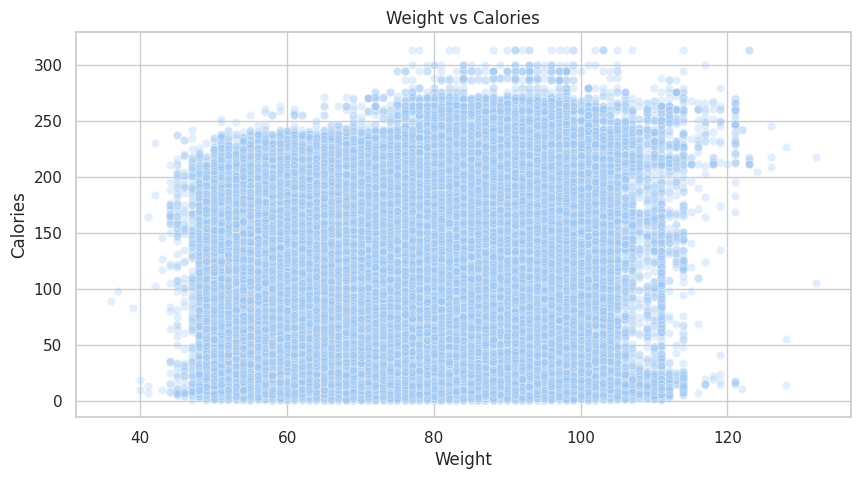

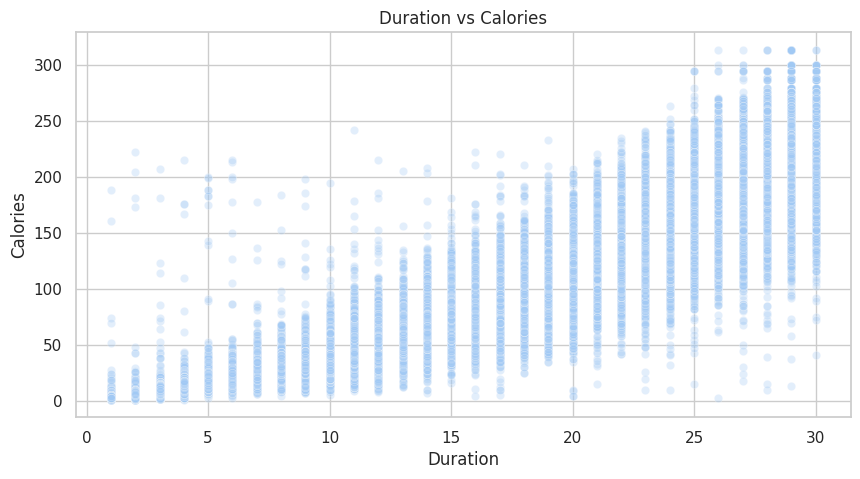

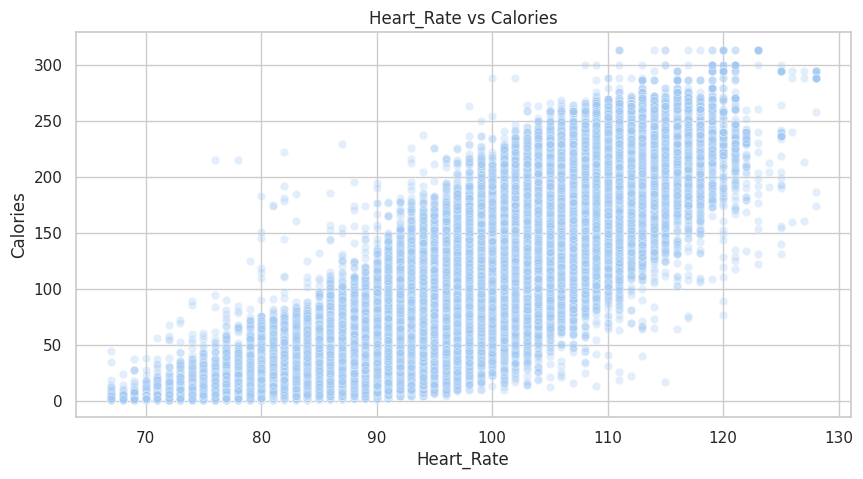

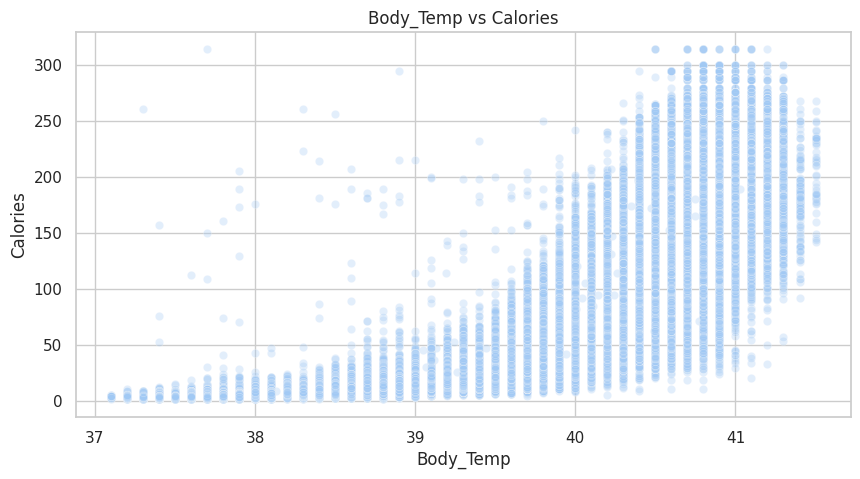

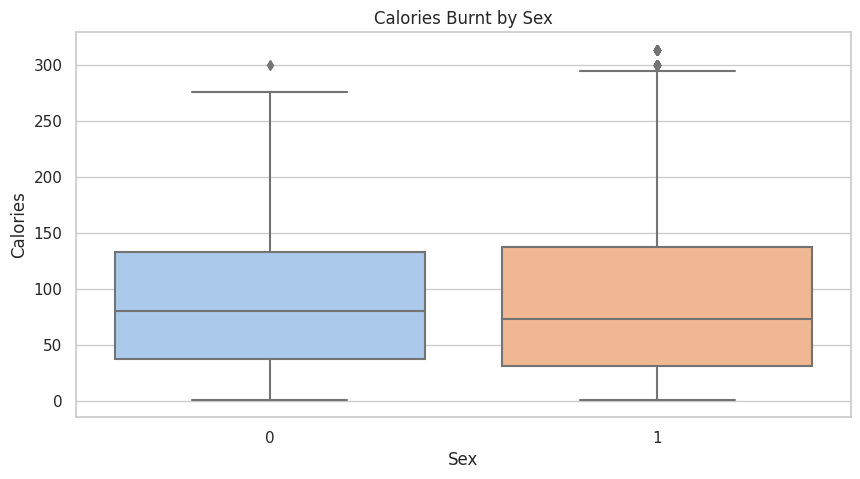

In [23]:
# Numerical Features vs Target (Calories)
for col in numeric_features:
    plt.figure()
    sns.scatterplot(data=train_df, x=col, y='Calories', alpha=0.3)
    plt.title(f'{col} vs Calories')
    plt.xlabel(col)
    plt.ylabel('Calories')
    plt.show()

# Categorical Feature vs Target (Boxplot)
plt.figure()
sns.boxplot(x='Sex', y='Calories', data=train_df)
plt.title('Calories Burnt by Sex')
plt.xlabel('Sex')
plt.ylabel('Calories')
plt.show()


<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 🔗 Bivariate Analysis

Bivariate analysis explores the relationship between two variables — particularly how features interact with the target variable `Calories`. Here's what we found:

### 🔹 Numerical Features vs Target

- **Age vs Calories**: A moderate upward trend is visible — older individuals may burn slightly more calories, possibly due to higher effort needed or physiological factors.
- **Weight vs Calories**: Strong positive correlation. Heavier individuals tend to burn more calories, as more energy is required to move higher body mass.
- **Duration vs Calories**: As expected, this shows the **strongest linear relationship**. Longer workouts lead to higher calorie expenditure.
- **Heart_Rate vs Calories**: A meaningful positive trend — higher heart rates often indicate more intense workouts, leading to greater calorie burn.
- **Body_Temp vs Calories**: Mild correlation; elevated body temperature may reflect intense effort or prolonged activity.

### 🔹 Categorical Feature vs Target

- **Sex vs Calories**: From the boxplot, males and females exhibit slightly different calorie burn ranges. This could be attributed to physiological differences such as muscle mass or average body weight.

### 🔹 Correlation Matrix

The heatmap reveals:
- **Duration, Weight, and Heart_Rate** are most strongly correlated with `Calories`.
- **Multicollinearity** is minimal, suggesting features are largely independent — good for model performance.

> 🔎 **Why Bivariate Analysis Matters**  
It helps in:
- Understanding which features are most predictive of the target.
- Informing feature selection to avoid irrelevant or redundant variables.
- Validating expected real-world relationships (e.g., longer workouts = more calories).



# Encoding

In [25]:
encoder=LabelEncoder()
train_df['Sex']=encoder.fit_transform(train_df['Sex'])
train_df.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,1,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,0,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,0,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,1,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,0,38,166.0,61.0,25.0,102.0,40.6,146.0


# Multivariate Analysis

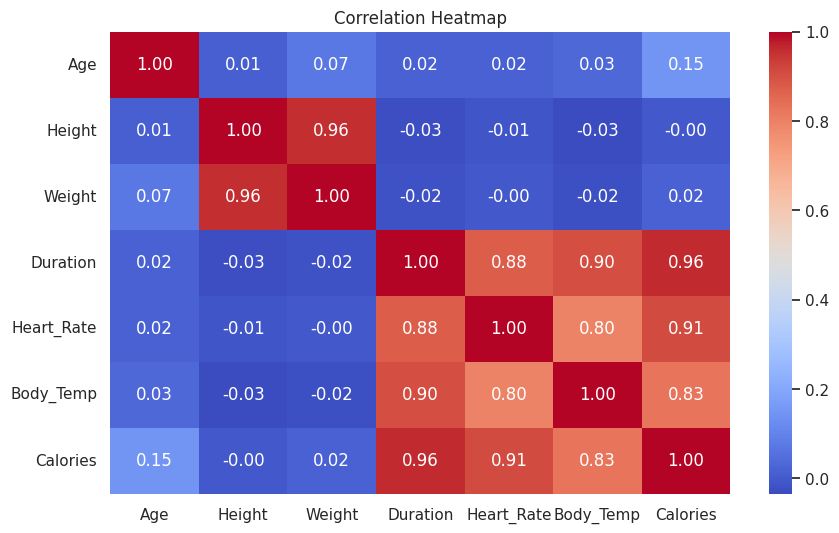

In [26]:
corr = train_df.drop(columns=['id', 'Sex']).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

# Modeling

## Train

In [27]:
X = train_df.drop(columns=['id', 'Calories'])
y = train_df['Calories']

In [28]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

In [31]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)
    results[name] = {"RMSE": rmse, "R2 Score": r2}

In [32]:
results_df = pd.DataFrame(results).T.sort_values(by="RMSE")
print("Validation Performance:")
print(results_df)

Validation Performance:
                        RMSE  R2 Score
XGBoost             3.800778  0.996273
Random Forest       3.822877  0.996229
Gradient Boosting   4.751223  0.994175
KNN                 4.901503  0.993801
Ridge Regression   11.058772  0.968445
Linear Regression  11.058772  0.968445


# Test

In [35]:
test_df = pd.read_csv('/kaggle/input/playground-series-s5e5/test.csv')
test_df['Sex'] = encoder.fit_transform(test_df['Sex'])
test_ids = test_df['id']
X_test = test_df.drop(columns=['id'])

In [38]:
best_model = models['XGBoost']
best_model.fit(X, y)
test_preds = best_model.predict(X_test)

In [39]:
# Load sample submission format
sample_submission = pd.read_csv('/kaggle/input/playground-series-s5e5/sample_submission.csv')

# Fill predictions
sample_submission['Calories'] = test_preds

# Save to CSV
sample_submission.to_csv('final_submission.csv', index=False)

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 🚀 Modeling Process & Model Comparison

To develop an accurate model for predicting the **Calories burnt**, we implemented and compared a set of regression algorithms. Our aim was to identify the model with the best generalization performance using common evaluation metrics such as **Root Mean Squared Error (RMSE)** and **R² Score**.

---

### 🔧 Modeling Approach

We followed a structured pipeline:

1. **Preprocessing**:
   - Encoded the categorical feature `Sex` using `LabelEncoder`.
   - Removed the non-informative `id` column.
   - Separated features (`X`) and the target (`Calories`).

2. **Train-Validation Split**:
   - Split the dataset into **80% training** and **20% validation** using `train_test_split`.

3. **Model Selection**:
   We trained six different models, including both linear and ensemble-based approaches:
   - Linear Regression
   - Ridge Regression
   - K-Nearest Neighbors (KNN)
   - Random Forest Regressor
   - Gradient Boosting Regressor
   - XGBoost Regressor

4. **Evaluation Metrics**:
   - **RMSE**: Lower values indicate better performance.
   - **R² Score**: Values closer to 1 indicate a better fit.

---

### 📊 Model Performance on Validation Set

| Model                  | RMSE       | R² Score   |
|------------------------|------------|------------|
| **XGBoost Regressor**  | **3.80**   | **0.9963** |
| Random Forest Regressor| 3.82       | 0.9962     |
| K-Nearest Neighbors    | 4.50       | 0.9948     |
| Gradient Boosting      | 4.75       | 0.9942     |
| Ridge Regression       | 11.06      | 0.9684     |
| Linear Regression      | 11.06      | 0.9684     |

---

### ✅ Best Model

Based on the results above, **XGBoost Regressor** delivered the best performance on the validation set with:
- The **lowest RMSE** (3.80)
- The **highest R² Score** (0.9963)

This indicates that XGBoost was able to learn complex patterns in the data and generalize well to unseen examples. We selected this model to make predictions on the test dataset.

---
